# Case 2: Reaction Time and Distance

## FIFA Rule (Law 12 – IFAB)
A handball offence considers whether the player **had time and distance to react** to the ball. The law does not define exact values — referees must judge subjectively whether the player could have avoided the contact.

**Reference:** IFAB – Laws of the Game, Law 12.

## Why This Is Debatable
- Fast shots give players very little time to react.
- Humans are poor at estimating time intervals under ~500ms.
- Referees must guess whether a player "could have" moved their arm — a subjective judgement.
- Camera replays at different speeds distort perception of reaction time.

## How AI Can Help
### Approach
- **Track the ball** across consecutive frames to measure its speed (pixels/frame).
- **Measure the distance** between the ball and the nearest player's arm.
- **Calculate the reaction time** the player had: `time = distance / ball_speed`.
- All measurements are **relative** — no real-world calibration is needed. The reaction time is derived from the ball's own travel speed in the video, ensuring standardization.

### AI Model
- **YOLOv8-pose** for player body keypoints (arm positions).
- **YOLOv8x** (or custom model) for ball detection.
- **Simple physics-based calculations** for speed and reaction time.

### Decision Logic
| Available Reaction Time | Verdict |
|------------------------|---------|
| < 200 ms | **No Foul** — Player had no time to react |
| 200 ms – 400 ms | **Debatable** — Borderline reaction time |
| > 400 ms | **Possible Foul** — Player had enough time to move arm |

### Result
AI provides **clear numerical values** (ball speed, distance, reaction time in milliseconds) instead of subjective guesses, giving referees objective data to support their decision.

## Step 1 – Import Libraries
We import:
- **cv2** (OpenCV) for video/image processing
- **numpy** for numerical operations
- **YOLO** from ultralytics for pose estimation and ball detection
- **matplotlib** for displaying frames inline
- **math** for distance and speed calculations
- **collections.deque** for efficient ball position history tracking

In [ ]:
# installing ultralytics package
!pip install ultralytics

In [11]:
import cv2
import numpy as np
import math
from collections import deque
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Display images inline in the notebook
%matplotlib inline

## Step 2 – Configuration

We define:
- **VIDEO_PATH / OUTPUT_PATH**: Input and output video paths.
- **MODEL_POSE / MODEL_BALL**: The YOLOv8 models for pose estimation and ball detection.
- **BALL_HISTORY_LENGTH**: How many past frames to keep for computing ball speed (smoothing).
- **BALL_DISTANCE_THRESHOLD**: Maximum pixel distance to consider ball-arm "contact".

### Reaction Time Thresholds
Human visual reaction time to an unexpected stimulus is approximately **200–250 ms**. We define three zones:

| Threshold | Meaning |
|-----------|---------|
| < 200 ms | Player **cannot** react — no foul |
| 200–400 ms | **Borderline** — debatable |
| > 400 ms | Player **had time** to react — possible foul |

### How Ball Speed Is Calculated
We track the ball's center position across consecutive frames. The **speed** is the Euclidean distance (in pixels) the ball travels per frame. Using the video's FPS, we convert this to pixels/second. Then:

$$\text{Reaction Time (seconds)} = \frac{\text{Distance from ball to arm (pixels)}}{\text{Ball speed (pixels/second)}}$$

This gives the time the ball took to travel from its previous position to the player's arm — the time window the player had to react.

In [12]:
# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
VIDEO_PATH = "../input.mp4"                                  # Input football video
OUTPUT_PATH = "../output/case2_reaction_time.mp4"            # Output annotated video
MODEL_POSE = "../yolov8n-pose.pt"                            # YOLOv8 Pose estimation model
MODEL_BALL = "../yolov8x.pt"                                 # YOLOv8 Ball detection model

# Keypoint indices (COCO format used by YOLOv8-pose)
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_ELBOW = 7
RIGHT_ELBOW = 8
LEFT_WRIST = 9
RIGHT_WRIST = 10
LEFT_HIP = 11
RIGHT_HIP = 12

# Ball tracking history length (number of past frames to keep for speed smoothing)
BALL_HISTORY_LENGTH = 5

# Ball proximity threshold (in pixels)
# If the ball center is within this distance of an arm keypoint, we consider it "contact"
BALL_DISTANCE_THRESHOLD = 150

# Reaction time thresholds (in milliseconds)
REACTION_TIME_NO_FOUL = 200      # Below this: player cannot react → NO FOUL
REACTION_TIME_DEBATABLE = 400    # Between NO_FOUL and this: borderline → DEBATABLE
# Above DEBATABLE: player had enough time → POSSIBLE FOUL

# COCO class ID for "sports ball"
# If using a custom-trained model where ball = class 0, set this to [0]
BALL_CLASS_ID = [32]   # 32 = sports ball in COCO

print("Configuration loaded.")

Configuration loaded.


## Step 3 – Helper Functions

### Ball Tracking & Speed Calculation
We maintain a **history** of ball positions (deque of recent frames). The ball speed is computed as:

$$\text{speed (px/frame)} = \frac{1}{N-1} \sum_{i=1}^{N-1} \sqrt{(x_i - x_{i-1})^2 + (y_i - y_{i-1})^2}$$

This averaged speed reduces noise from detection jitter. We then convert to real time using FPS:

$$\text{speed (px/s)} = \text{speed (px/frame)} \times \text{FPS}$$

### Reaction Time Calculation
When the ball is near a player's arm, the reaction time is:

$$t_{\text{react}} = \frac{d_{\text{ball→arm}}}{\text{speed (px/s)}} \times 1000 \quad \text{(milliseconds)}$$

This represents how long the ball took to cross the distance to the player's arm — which is the time window the player had to pull their arm away.

### Why Relative Measurements Work
Since both the distance and the speed are measured in pixels within the same video frame, the ratio gives a **time value that is independent of camera zoom, resolution, or scale**. A ball moving fast across 200px takes the same real-world time as captured in the video — no calibration needed.

In [13]:
def get_ball_center(ball_results):
    """
    Extract the ball center from detection results.
    Returns the center (cx, cy) of the highest-confidence ball detection,
    or None if no ball is detected.
    """
    if len(ball_results[0].boxes) > 0:
        # Pick the detection with the highest confidence
        best_box = None
        best_conf = 0
        for box in ball_results[0].boxes:
            conf = float(box.conf[0])
            if conf > best_conf:
                best_conf = conf
                best_box = box
        if best_box is not None:
            x1, y1, x2, y2 = best_box.xyxy[0].cpu().numpy()
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            return (cx, cy)
    return None


def get_all_ball_centers(ball_results):
    """
    Extract all ball center points from detection results.
    Returns a list of (cx, cy) tuples.
    """
    centers = []
    if len(ball_results[0].boxes) > 0:
        for box in ball_results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            centers.append((cx, cy))
    return centers


def calculate_ball_speed(ball_history, fps):
    """
    Calculate ball speed from the position history.
    
    Args:
        ball_history: deque of (cx, cy) tuples from recent frames
        fps: video frames per second
    
    Returns:
        speed_px_per_sec: ball speed in pixels/second (averaged over history)
        speed_px_per_frame: ball speed in pixels/frame
        Returns (None, None) if not enough history
    """
    if len(ball_history) < 2:
        return None, None
    
    # Calculate displacement between each consecutive pair of positions
    displacements = []
    for i in range(1, len(ball_history)):
        prev = ball_history[i - 1]
        curr = ball_history[i]
        dx = curr[0] - prev[0]
        dy = curr[1] - prev[1]
        dist = math.sqrt(dx**2 + dy**2)
        displacements.append(dist)
    
    # Average speed in pixels per frame
    speed_px_per_frame = sum(displacements) / len(displacements)
    
    # Convert to pixels per second
    speed_px_per_sec = speed_px_per_frame * fps
    
    return speed_px_per_sec, speed_px_per_frame


def is_keypoint_valid(kp):
    """Check if a keypoint was actually detected (not at origin 0,0)."""
    return kp[0] != 0 or kp[1] != 0


def min_distance_to_ball(arm_keypoints, ball_centers):
    """
    Calculate the minimum Euclidean distance between any arm keypoint
    and any detected ball center.
    
    Args:
        arm_keypoints: list of (x, y) arrays — the elbow and wrist positions
        ball_centers:  list of (cx, cy) tuples — detected ball centers
    
    Returns:
        (min_dist, closest_arm_point, closest_ball_point) or (None, None, None)
    """
    min_dist = float('inf')
    closest_arm = None
    closest_ball = None
    
    for kp in arm_keypoints:
        if not is_keypoint_valid(kp):
            continue
        for bc in ball_centers:
            dist = math.sqrt((kp[0] - bc[0])**2 + (kp[1] - bc[1])**2)
            if dist < min_dist:
                min_dist = dist
                closest_arm = kp
                closest_ball = bc
    
    if min_dist == float('inf'):
        return None, None, None
    return min_dist, closest_arm, closest_ball


def calculate_reaction_time_ms(distance_px, ball_speed_px_per_sec):
    """
    Calculate the reaction time a player had, in milliseconds.
    
    This is the time the ball took to travel the given distance at its current speed.
    
    Args:
        distance_px: distance from ball to arm in pixels
        ball_speed_px_per_sec: ball speed in pixels/second
    
    Returns:
        reaction_time_ms: time in milliseconds, or None if speed is too low/unknown
    """
    if ball_speed_px_per_sec is None or ball_speed_px_per_sec < 1.0:
        # Ball is essentially stationary or speed unknown
        return None
    
    time_seconds = distance_px / ball_speed_px_per_sec
    return time_seconds * 1000  # Convert to milliseconds


def classify_reaction_time(reaction_time_ms):
    """
    Classify the reaction time into a verdict.
    
    Returns:
        - "NO FOUL"       if reaction_time < REACTION_TIME_NO_FOUL (too fast to react)
        - "DEBATABLE"     if between NO_FOUL and DEBATABLE thresholds
        - "POSSIBLE FOUL" if reaction_time > REACTION_TIME_DEBATABLE (player had time)
        - "UNKNOWN"       if reaction_time is None
    """
    if reaction_time_ms is None:
        return "UNKNOWN"
    if reaction_time_ms < REACTION_TIME_NO_FOUL:
        return "NO FOUL"
    elif reaction_time_ms <= REACTION_TIME_DEBATABLE:
        return "DEBATABLE"
    else:
        return "POSSIBLE FOUL"


def get_verdict_color(verdict):
    """Return a BGR color based on the reaction time verdict."""
    if verdict == "NO FOUL":
        return (0, 255, 0)      # Green — player couldn't react
    elif verdict == "DEBATABLE":
        return (0, 165, 255)    # Orange — borderline
    elif verdict == "POSSIBLE FOUL":
        return (0, 0, 255)      # Red — player had time
    else:
        return (200, 200, 200)  # Grey — unknown


print("Helper functions defined.")

Helper functions defined.


## Step 4 – Load the Models

We load the same **two models** as Case 1:
1. **YOLOv8n-pose** — detects 17 body keypoints per person. Used to locate arm positions.
2. **YOLOv8x** (or custom-trained model) — detects the football. Used to track ball position and compute speed.

In [14]:
# Load the YOLOv8 Pose Estimation model
print("Loading pose estimation model...")
pose_model = YOLO(MODEL_POSE)
print("Pose model loaded successfully!")

# Load the YOLOv8 Ball Detection model
print("Loading ball detection model...")
ball_model = YOLO(MODEL_BALL)
print("Ball model loaded successfully!")

Loading pose estimation model...
Pose model loaded successfully!
Loading ball detection model...


Ball model loaded successfully!


## Step 5 – Test Ball Speed Tracking on a Few Frames

Before processing the entire video, let's read the first few frames to verify:
1. The ball is detected correctly.
2. Ball speed is computed from frame-to-frame displacement.
3. The reaction time calculation produces sensible values.

We'll read 10 frames, track the ball position, and show the computed speed.

In [15]:
# Test ball tracking on the first 10 frames
cap = cv2.VideoCapture(VIDEO_PATH)
fps = int(cap.get(cv2.CAP_PROP_FPS))

if not cap.isOpened():
    print(f"Error: Could not open video {VIDEO_PATH}")
else:
    ball_history = deque(maxlen=BALL_HISTORY_LENGTH)
    test_frames = []
    
    print(f"Video FPS: {fps}")
    print(f"Ball history window: {BALL_HISTORY_LENGTH} frames")
    print("-" * 60)
    
    for i in range(10):
        ret, frame = cap.read()
        if not ret:
            break
        
        # Detect ball
        ball_results = ball_model(frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)
        ball_center = get_ball_center(ball_results)
        
        if ball_center is not None:
            ball_history.append(ball_center)
        
        # Calculate speed
        speed_px_s, speed_px_f = calculate_ball_speed(ball_history, fps)
        
        # Print results
        ball_str = f"({ball_center[0]:.0f}, {ball_center[1]:.0f})" if ball_center else "Not detected"
        speed_str = f"{speed_px_s:.1f} px/s ({speed_px_f:.1f} px/frame)" if speed_px_s else "N/A"
        print(f"Frame {i+1:2d} | Ball: {ball_str:>20s} | Speed: {speed_str}")
        
        # Save last frame for display
        if i == 9:
            test_frames.append(frame)
    
    cap.release()
    
    print("-" * 60)
    if speed_px_s:
        print(f"Latest ball speed: {speed_px_s:.1f} px/s")
        # Example: what reaction time would a player at 100px distance have?
        example_dist = 100
        example_rt = calculate_reaction_time_ms(example_dist, speed_px_s)
        if example_rt:
            print(f"Example: At {example_dist}px distance → reaction time = {example_rt:.1f} ms → {classify_reaction_time(example_rt)}")
    else:
        print("Could not compute ball speed (ball not detected in enough frames).")

Video FPS: 29
Ball history window: 5 frames
------------------------------------------------------------
Frame  1 | Ball:           (192, 245) | Speed: N/A
Frame  2 | Ball:           (192, 245) | Speed: N/A
Frame  3 | Ball:           (199, 244) | Speed: 101.7 px/s (3.5 px/frame)
Frame  4 | Ball:           (206, 244) | Speed: 135.2 px/s (4.7 px/frame)
Frame  5 | Ball:           (213, 244) | Speed: 146.8 px/s (5.1 px/frame)
Frame  6 | Ball:           (218, 244) | Speed: 187.0 px/s (6.4 px/frame)
Frame  7 | Ball:           (223, 245) | Speed: 174.3 px/s (6.0 px/frame)
Frame  8 | Ball:           (224, 245) | Speed: 125.4 px/s (4.3 px/frame)
Frame  9 | Ball:         Not detected | Speed: 125.4 px/s (4.3 px/frame)
Frame 10 | Ball:           (233, 247) | Speed: 148.4 px/s (5.1 px/frame)
------------------------------------------------------------
Latest ball speed: 148.4 px/s
Example: At 100px distance → reaction time = 673.9 ms → POSSIBLE FOUL


## Step 6 – Single Frame Analysis with Reaction Time

Let's test the full analysis on a single frame with ball speed context from the preceding frames. This lets us:
1. See the ball detection and its tracked speed.
2. See the distance from the ball to each player's arm.
3. See the **calculated reaction time** and the resulting verdict.

The visualization shows:
- **Orange box** around the ball with its speed label.
- **Dashed lines** from the ball to the nearest arm keypoint with distance and reaction time.
- **Color-coded verdict** at the top of the frame.

Ball speed: 138.6 px/s
Detected 0 ball(s) in the frame.

No persons detected in the frame.


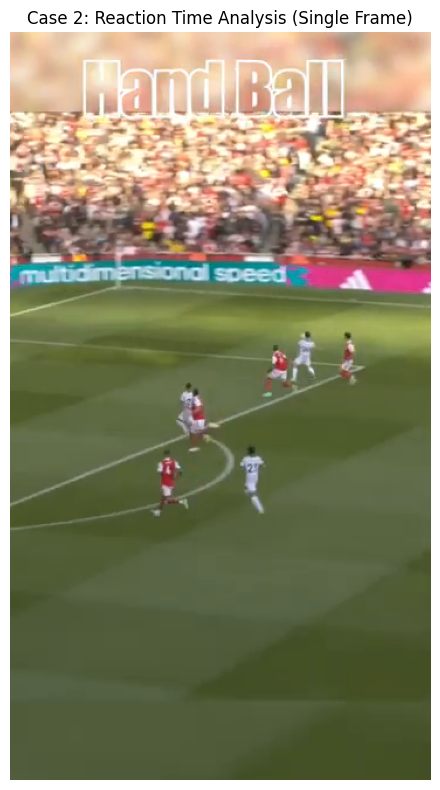

In [16]:
# Analyze a single frame with reaction time context
# We read 20 frames to build up ball speed history, then analyze the last one

cap = cv2.VideoCapture(VIDEO_PATH)
fps = int(cap.get(cv2.CAP_PROP_FPS))

if not cap.isOpened():
    print(f"Error: Could not open video {VIDEO_PATH}")
else:
    ball_history = deque(maxlen=BALL_HISTORY_LENGTH)
    analysis_frame = None
    
    # Read 20 frames to build ball speed context
    for i in range(20):
        ret, frame = cap.read()
        if not ret:
            break
        
        ball_results = ball_model(frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)
        ball_center = get_ball_center(ball_results)
        if ball_center is not None:
            ball_history.append(ball_center)
        
        analysis_frame = frame
    
    cap.release()
    
    if analysis_frame is None:
        print("Error: Could not read frames from video.")
    else:
        # Run both models on the analysis frame
        pose_results = pose_model(analysis_frame, verbose=False, conf=0.5)
        ball_results = ball_model(analysis_frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)
        
        # Get ball speed from history
        ball_speed_px_s, ball_speed_px_f = calculate_ball_speed(ball_history, fps)
        ball_centers = get_all_ball_centers(ball_results)
        
        # Start with pose-annotated frame
        annotated = pose_results[0].plot()
        
        # --- Draw ball detections with speed ---
        for box in ball_results[0].boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 165, 255), 3)
            speed_label = f"BALL | {ball_speed_px_s:.0f} px/s" if ball_speed_px_s else "BALL | Speed: N/A"
            cv2.putText(annotated, speed_label, (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)
        
        print(f"Ball speed: {ball_speed_px_s:.1f} px/s" if ball_speed_px_s else "Ball speed: N/A")
        print(f"Detected {len(ball_centers)} ball(s) in the frame.\n")
        
        # --- Analyze each detected person ---
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
            keypoints = pose_results[0].keypoints.xy.cpu().numpy()
            print(f"Detected {len(keypoints)} person(s) in the frame.\n")
            
            for person_idx, kpts in enumerate(keypoints):
                print(f"--- Person {person_idx + 1} ---")
                
                # Collect all arm keypoints for this person
                arm_kps = []
                for idx in [LEFT_ELBOW, RIGHT_ELBOW, LEFT_WRIST, RIGHT_WRIST]:
                    if is_keypoint_valid(kpts[idx]):
                        arm_kps.append(kpts[idx])
                
                # Find minimum distance to ball
                dist, arm_pt, ball_pt = min_distance_to_ball(arm_kps, ball_centers)
                
                if dist is not None:
                    # Calculate reaction time
                    reaction_time = calculate_reaction_time_ms(dist, ball_speed_px_s)
                    verdict = classify_reaction_time(reaction_time)
                    color = get_verdict_color(verdict)
                    
                    rt_str = f"{reaction_time:.0f} ms" if reaction_time else "N/A"
                    print(f"  Ball-to-arm distance: {dist:.0f} px")
                    print(f"  Reaction time:        {rt_str}")
                    print(f"  Verdict:              {verdict}")
                    
                    # Draw distance line
                    pt1 = (int(arm_pt[0]), int(arm_pt[1]))
                    pt2 = (int(ball_pt[0]), int(ball_pt[1]))
                    cv2.line(annotated, pt1, pt2, color, 2)
                    
                    # Label with distance and reaction time
                    mid = ((pt1[0] + pt2[0]) // 2, (pt1[1] + pt2[1]) // 2)
                    label = f"{dist:.0f}px | {rt_str}"
                    cv2.putText(annotated, label, (mid[0], mid[1] - 10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
                    cv2.putText(annotated, verdict, (mid[0], mid[1] + 15),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
                else:
                    print("  No ball near arm detected.")
                print()
        else:
            print("No persons detected in the frame.")
        
        # Display
        plt.figure(figsize=(14, 8))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title("Case 2: Reaction Time Analysis (Single Frame)")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

## Step 7 – Process the Full Video

Now we process the entire video frame-by-frame. For each frame, we:

1. **Detect the ball** and update the position history to compute speed.
2. **Detect all players** and their arm keypoints (elbow, wrist).
3. **Calculate the distance** from the ball to each player's nearest arm keypoint.
4. **Calculate the reaction time** using: `time = distance / ball_speed`.
5. **Classify the verdict**:
   - 🟢 **No Foul** (< 200 ms) — Ball was too fast for the player to react.
   - 🟠 **Debatable** (200–400 ms) — Borderline reaction time.
   - 🔴 **Possible Foul** (> 400 ms) — Player had enough time to move their arm.
6. **Annotate the frame** with ball speed, distance, reaction time, and verdict.
7. **Save the annotated video** to output.

In [17]:
def process_video_case2(video_path, output_path, pose_model, ball_model):
    """
    Process a football video to evaluate handball fouls based on Case 2:
    Reaction Time and Distance (FIFA Law 12).
    
    Tracks ball speed across frames and calculates whether each player
    had sufficient reaction time when the ball approached their arm.
    
    Returns:
        dict with keys:
          - 'no_foul_frames':      frames where player couldn't react (< 200ms)
          - 'debatable_frames':    frames with borderline reaction time (200-400ms)
          - 'possible_foul_frames': frames where player had time to react (> 400ms)
          - 'total_frames':        total frames processed
          - 'ball_speed_log':      list of (frame_num, speed_px_s) for plotting
          - 'reaction_time_log':   list of (frame_num, reaction_time_ms, verdict) for events
    """
    
    # Open input video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None
    
    # Video properties
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Create output video writer
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    
    print(f"Processing video: {width}x{height} @ {fps}fps ({total_frames} frames)")
    print(f"Output: {output_path}")
    print(f"Reaction time thresholds: NO FOUL < {REACTION_TIME_NO_FOUL}ms | DEBATABLE {REACTION_TIME_NO_FOUL}-{REACTION_TIME_DEBATABLE}ms | POSSIBLE FOUL > {REACTION_TIME_DEBATABLE}ms")
    print(f"Ball proximity threshold: {BALL_DISTANCE_THRESHOLD}px")
    print(f"Ball speed smoothing window: {BALL_HISTORY_LENGTH} frames")
    print("-" * 70)
    
    # Tracking state
    ball_history = deque(maxlen=BALL_HISTORY_LENGTH)
    frame_count = 0
    
    # Result logs
    no_foul_frames = []
    debatable_frames = []
    possible_foul_frames = []
    ball_speed_log = []          # (frame_num, speed_px_s)
    reaction_time_log = []       # (frame_num, reaction_time_ms, verdict)
    
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break
        
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processing frame {frame_count}/{total_frames}...")
        
        # ---- Run AI models ----
        pose_results = pose_model(frame, verbose=False, conf=0.5)
        ball_results = ball_model(frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)
        
        # ---- Track ball position and speed ----
        ball_center = get_ball_center(ball_results)
        if ball_center is not None:
            ball_history.append(ball_center)
        
        ball_speed_px_s, ball_speed_px_f = calculate_ball_speed(ball_history, fps)
        
        # Log ball speed
        if ball_speed_px_s is not None:
            ball_speed_log.append((frame_count, ball_speed_px_s))
        
        # Start with pose-annotated frame
        annotated_frame = pose_results[0].plot()
        
        # ---- Draw ball detection with speed ----
        ball_centers = get_all_ball_centers(ball_results)
        for box in ball_results[0].boxes:
            bx1, by1, bx2, by2 = map(int, box.xyxy[0])
            cv2.rectangle(annotated_frame, (bx1, by1), (bx2, by2), (0, 165, 255), 3)
            if ball_speed_px_s is not None:
                speed_label = f"BALL | {ball_speed_px_s:.0f} px/s"
            else:
                speed_label = "BALL"
            cv2.putText(annotated_frame, speed_label, (bx1, by1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 165, 255), 2)
        
        # ---- Frame-level verdict (worst case across all players) ----
        frame_verdict = "NO FOUL"
        frame_verdict_color = (0, 255, 0)
        frame_best_reaction_time = None
        
        # ---- Analyze each detected person ----
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
            keypoints = pose_results[0].keypoints.xy.cpu().numpy()
            
            for person_idx, kpts in enumerate(keypoints):
                # Collect arm keypoints (elbows + wrists)
                arm_kps = []
                for idx in [LEFT_ELBOW, RIGHT_ELBOW, LEFT_WRIST, RIGHT_WRIST]:
                    if is_keypoint_valid(kpts[idx]):
                        arm_kps.append(kpts[idx])
                
                if not arm_kps:
                    continue
                
                # Find minimum distance to ball
                dist, arm_pt, ball_pt = min_distance_to_ball(arm_kps, ball_centers)
                
                if dist is None or dist > BALL_DISTANCE_THRESHOLD:
                    continue  # Ball not close enough — skip
                
                # ---- Calculate reaction time ----
                reaction_time = calculate_reaction_time_ms(dist, ball_speed_px_s)
                verdict = classify_reaction_time(reaction_time)
                color = get_verdict_color(verdict)
                
                # Draw distance line from ball to arm
                pt1 = (int(arm_pt[0]), int(arm_pt[1]))
                pt2 = (int(ball_pt[0]), int(ball_pt[1]))
                cv2.line(annotated_frame, pt1, pt2, color, 2)
                
                # Label with distance + reaction time
                mid = ((pt1[0] + pt2[0]) // 2, (pt1[1] + pt2[1]) // 2)
                if reaction_time is not None:
                    label = f"{dist:.0f}px | {reaction_time:.0f}ms"
                else:
                    label = f"{dist:.0f}px | RT: N/A"
                cv2.putText(annotated_frame, label, (mid[0] - 40, mid[1] - 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                cv2.putText(annotated_frame, verdict, (mid[0] - 40, mid[1] + 15),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                
                # Highlight the arm keypoint
                cv2.circle(annotated_frame, pt1, 8, color, -1)
                
                # Update frame-level verdict (escalate only)
                if verdict == "POSSIBLE FOUL":
                    frame_verdict = "POSSIBLE FOUL"
                    frame_verdict_color = (0, 0, 255)
                    if frame_best_reaction_time is None or (reaction_time and reaction_time > frame_best_reaction_time):
                        frame_best_reaction_time = reaction_time
                elif verdict == "DEBATABLE" and frame_verdict != "POSSIBLE FOUL":
                    frame_verdict = "DEBATABLE"
                    frame_verdict_color = (0, 165, 255)
                    if frame_best_reaction_time is None or (reaction_time and reaction_time > frame_best_reaction_time):
                        frame_best_reaction_time = reaction_time
                elif verdict == "NO FOUL" and frame_verdict not in ["POSSIBLE FOUL", "DEBATABLE"]:
                    if frame_best_reaction_time is None or (reaction_time and reaction_time < (frame_best_reaction_time or float('inf'))):
                        frame_best_reaction_time = reaction_time
        
        # ---- Draw frame-level banner ----
        if frame_verdict == "POSSIBLE FOUL" and frame_best_reaction_time is not None:
            possible_foul_frames.append(frame_count)
            reaction_time_log.append((frame_count, frame_best_reaction_time, "POSSIBLE FOUL"))
            cv2.putText(annotated_frame, "POSSIBLE FOUL - Player had time to react", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
            cv2.putText(annotated_frame, f"Reaction time: {frame_best_reaction_time:.0f} ms (> {REACTION_TIME_DEBATABLE} ms)",
                       (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
        elif frame_verdict == "DEBATABLE" and frame_best_reaction_time is not None:
            debatable_frames.append(frame_count)
            reaction_time_log.append((frame_count, frame_best_reaction_time, "DEBATABLE"))
            cv2.putText(annotated_frame, "DEBATABLE - Borderline reaction time", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 165, 255), 1)
            cv2.putText(annotated_frame, f"Reaction time: {frame_best_reaction_time:.0f} ms ({REACTION_TIME_NO_FOUL}-{REACTION_TIME_DEBATABLE} ms)",
                       (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 165, 255), 1)
        elif frame_best_reaction_time is not None:
            no_foul_frames.append(frame_count)
            reaction_time_log.append((frame_count, frame_best_reaction_time, "NO FOUL"))
        
        # Draw persistent speed info in top-right corner
        if ball_speed_px_s is not None:
            speed_text = f"Ball Speed: {ball_speed_px_s:.0f} px/s"
            cv2.putText(annotated_frame, speed_text, (width - 350, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)
        
        # Write annotated frame
        out.write(annotated_frame)
    
    # Cleanup
    cap.release()
    out.release()
    
    # Build results
    results = {
        'no_foul_frames': no_foul_frames,
        'debatable_frames': debatable_frames,
        'possible_foul_frames': possible_foul_frames,
        'total_frames': frame_count,
        'fps': fps,
        'ball_speed_log': ball_speed_log,
        'reaction_time_log': reaction_time_log,
    }
    
    print("-" * 70)
    print(f"Done! Processed {frame_count} frames.")
    print(f"POSSIBLE FOUL frames:  {len(possible_foul_frames)}/{frame_count} ({100*len(possible_foul_frames)/max(frame_count,1):.1f}%)")
    print(f"DEBATABLE frames:      {len(debatable_frames)}/{frame_count} ({100*len(debatable_frames)/max(frame_count,1):.1f}%)")
    print(f"NO FOUL frames:        {len(no_foul_frames)}/{frame_count} ({100*len(no_foul_frames)/max(frame_count,1):.1f}%)")
    other = frame_count - len(possible_foul_frames) - len(debatable_frames) - len(no_foul_frames)
    print(f"No contact frames:     {other}/{frame_count}")
    print(f"\nOutput saved to: {output_path}")
    
    if possible_foul_frames:
        print(f"\n⚠️  VERDICT: POSSIBLE HANDBALL FOUL in {len(possible_foul_frames)} frame(s) — player had time to react.")
        print(f"    Frames: {possible_foul_frames[:20]}{'...' if len(possible_foul_frames) > 20 else ''}")
    elif debatable_frames:
        print(f"\n⚠️  VERDICT: DEBATABLE in {len(debatable_frames)} frame(s) — borderline reaction time.")
        print(f"    Frames: {debatable_frames[:20]}{'...' if len(debatable_frames) > 20 else ''}")
    else:
        print(f"\n✅ VERDICT: NO FOUL — player(s) had insufficient time to react in all contact frames.")
    
    return results


print("Video processing function defined.")

Video processing function defined.


## Step 8 – Run the Video Processing

Execute the full video processing pipeline. This will track the ball across every frame, compute speed, and evaluate reaction time for every player-ball proximity event.

In [18]:
# Run the full video processing pipeline for Case 2
# The returned 'results' dict contains frame logs and reaction time data
results = process_video_case2(VIDEO_PATH, OUTPUT_PATH, pose_model, ball_model)

Processing video: 360x640 @ 29fps (253 frames)
Output: ../output/case2_reaction_time.mp4
Reaction time thresholds: NO FOUL < 200ms | DEBATABLE 200-400ms | POSSIBLE FOUL > 400ms
Ball proximity threshold: 150px
Ball speed smoothing window: 5 frames
----------------------------------------------------------------------


Processing frame 30/253...
Processing frame 60/253...
Processing frame 90/253...
Processing frame 120/253...
Processing frame 150/253...
Processing frame 180/253...
Processing frame 210/253...
Processing frame 240/253...
----------------------------------------------------------------------
Done! Processed 253 frames.
POSSIBLE FOUL frames:  58/253 (22.9%)
DEBATABLE frames:      12/253 (4.7%)
NO FOUL frames:        27/253 (10.7%)
No contact frames:     156/253

Output saved to: ../output/case2_reaction_time.mp4

⚠️  VERDICT: POSSIBLE HANDBALL FOUL in 58 frame(s) — player had time to react.
    Frames: [3, 4, 5, 6, 8, 11, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]...


## Step 9 – Visualize Ball Speed and Reaction Time

We plot two charts that give insight into the analysis:

### Chart 1: Ball Speed Over Time
Shows how the ball speed (px/s) varies throughout the video. Spikes indicate kicks, passes, or shots. This context helps understand why reaction times are short in some frames.

### Chart 2: Reaction Time Distribution
A histogram of all recorded reaction times when the ball was near a player's arm. The vertical dashed lines mark the threshold boundaries:
- **Green zone** (< 200 ms): No foul — too fast to react.
- **Orange zone** (200–400 ms): Debatable.
- **Red zone** (> 400 ms): Possible foul — player had time to react.

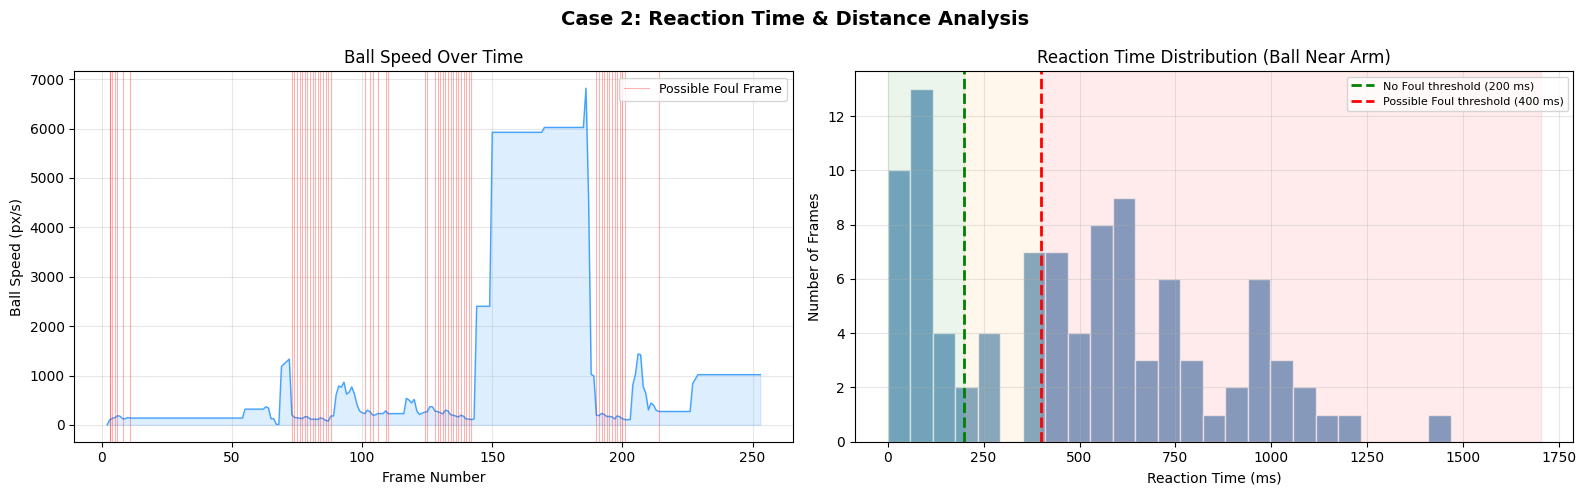


Reaction Time Statistics:
  Min:    9.4 ms
  Max:    1418.0 ms
  Mean:   490.3 ms
  Median: 503.6 ms


In [19]:
if results:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # ---- Chart 1: Ball Speed Over Time ----
    if results['ball_speed_log']:
        frames_s = [x[0] for x in results['ball_speed_log']]
        speeds = [x[1] for x in results['ball_speed_log']]
        
        axes[0].plot(frames_s, speeds, color='dodgerblue', linewidth=1, alpha=0.8)
        axes[0].fill_between(frames_s, speeds, alpha=0.15, color='dodgerblue')
        axes[0].set_xlabel('Frame Number')
        axes[0].set_ylabel('Ball Speed (px/s)')
        axes[0].set_title('Ball Speed Over Time')
        axes[0].grid(True, alpha=0.3)
        
        # Mark frames with possible fouls
        if results['possible_foul_frames']:
            for pf in results['possible_foul_frames']:
                axes[0].axvline(x=pf, color='red', alpha=0.3, linewidth=0.8)
            axes[0].axvline(x=results['possible_foul_frames'][0], color='red', alpha=0.3,
                           linewidth=0.8, label='Possible Foul Frame')
            axes[0].legend(fontsize=9)
    else:
        axes[0].text(0.5, 0.5, 'No ball speed data', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('Ball Speed Over Time')
    
    # ---- Chart 2: Reaction Time Distribution ----
    if results['reaction_time_log']:
        rt_values = [x[1] for x in results['reaction_time_log'] if x[1] is not None]
        
        if rt_values:
            # Histogram
            max_rt = min(max(rt_values) * 1.2, 2000)  # Cap at 2000ms for readability
            bins = np.linspace(0, max_rt, 30)
            axes[1].hist(rt_values, bins=bins, color='steelblue', edgecolor='white', alpha=0.7)
            
            # Threshold lines
            axes[1].axvline(x=REACTION_TIME_NO_FOUL, color='green', linestyle='--', linewidth=2,
                           label=f'No Foul threshold ({REACTION_TIME_NO_FOUL} ms)')
            axes[1].axvline(x=REACTION_TIME_DEBATABLE, color='red', linestyle='--', linewidth=2,
                           label=f'Possible Foul threshold ({REACTION_TIME_DEBATABLE} ms)')
            
            # Color zones
            axes[1].axvspan(0, REACTION_TIME_NO_FOUL, alpha=0.08, color='green')
            axes[1].axvspan(REACTION_TIME_NO_FOUL, REACTION_TIME_DEBATABLE, alpha=0.08, color='orange')
            axes[1].axvspan(REACTION_TIME_DEBATABLE, max_rt, alpha=0.08, color='red')
            
            axes[1].set_xlabel('Reaction Time (ms)')
            axes[1].set_ylabel('Number of Frames')
            axes[1].set_title('Reaction Time Distribution (Ball Near Arm)')
            axes[1].legend(fontsize=8)
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].text(0.5, 0.5, 'No reaction time data', ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title('Reaction Time Distribution')
    else:
        axes[1].text(0.5, 0.5, 'No ball-arm contact events', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Reaction Time Distribution')
    
    plt.suptitle('Case 2: Reaction Time & Distance Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # ---- Print summary statistics ----
    if results['reaction_time_log']:
        rt_values = [x[1] for x in results['reaction_time_log'] if x[1] is not None]
        if rt_values:
            print(f"\nReaction Time Statistics:")
            print(f"  Min:    {min(rt_values):.1f} ms")
            print(f"  Max:    {max(rt_values):.1f} ms")
            print(f"  Mean:   {np.mean(rt_values):.1f} ms")
            print(f"  Median: {np.median(rt_values):.1f} ms")
else:
    print("No results to visualize. Run the video processing first.")

## Step 10 – Preview Output Frames

Let's preview key frames from the output video. We prioritize:
1. **Possible Foul frames** (player had time to react) — shown first if any exist.
2. **Debatable frames** — shown if no possible fouls.
3. **Evenly sampled frames** — fallback if no contact events.

Look for:
- **Ball speed label** on the orange bounding box.
- **Distance + reaction time labels** on the lines connecting ball to arm.
- **Color-coded verdicts** (green = no foul, orange = debatable, red = possible foul).
- **Banner** at the top of the frame with the frame-level verdict.

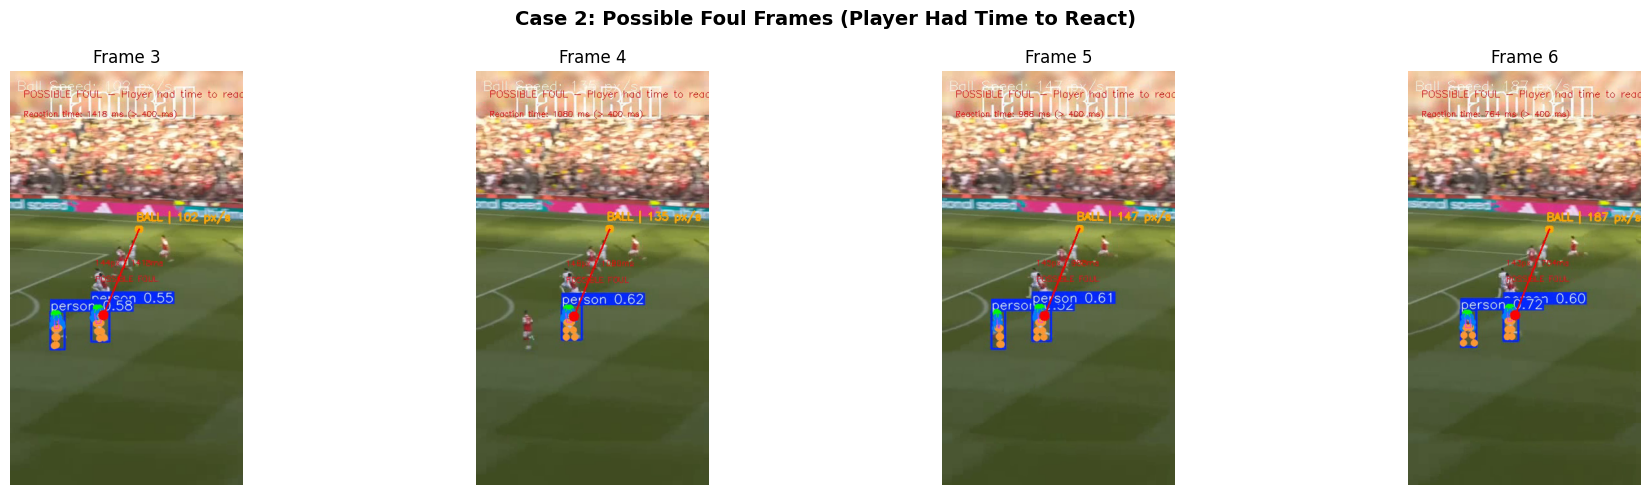

In [20]:
# Preview frames from the annotated output video
cap = cv2.VideoCapture(OUTPUT_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if results and results['possible_foul_frames']:
    sample_indices = results['possible_foul_frames'][:4]
    title = "Case 2: Possible Foul Frames (Player Had Time to React)"
elif results and results['debatable_frames']:
    sample_indices = results['debatable_frames'][:4]
    title = "Case 2: Debatable Frames (Borderline Reaction Time)"
elif results and results['no_foul_frames']:
    sample_indices = results['no_foul_frames'][:4]
    title = "Case 2: No Foul Frames (Ball Too Fast to React)"
else:
    sample_indices = [int(total * i / 4) for i in range(4)]
    title = "Case 2: Sample Frames (No Contact Events)"

n = min(len(sample_indices), 4)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for i, frame_idx in enumerate(sample_indices[:n]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx - 1)  # frame_idx is 1-based
    ret, frame = cap.read()
    if ret:
        axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Frame {frame_idx}")
        axes[i].axis('off')

cap.release()
plt.suptitle(title, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

### What This Notebook Does
This notebook implements **Case 2** of handball foul detection: evaluating whether a player had **sufficient reaction time and distance** to avoid the ball touching their arm (FIFA Law 12 – IFAB).

### How It Works — Relative Physics-Based Approach
1. **Ball Tracking**: The ball is detected in every frame using YOLOv8. Its center position is tracked across consecutive frames using a sliding window (deque).
2. **Ball Speed Calculation**: Speed is computed as the average displacement (pixels/frame) over the last 5 frames, then converted to pixels/second using the video's FPS. This smoothing reduces noise from detection jitter.
3. **Reaction Time Calculation**: When the ball is within proximity of a player's arm (elbow/wrist), the reaction time is:

$$t_{\text{react}} = \frac{d_{\text{ball→arm}}}{\text{ball speed}} \times 1000 \text{ ms}$$

4. **Verdict Classification**:

| Available Reaction Time | Verdict | Meaning |
|------------------------|---------|---------|
| < 200 ms | **No Foul** | Ball was too fast — player could not physically react |
| 200 – 400 ms | **Debatable** | Borderline — some elite athletes might react in time |
| > 400 ms | **Possible Foul** | Player had enough time to move their arm away |

### Why Relative Measurements Are Standardized
- Both distance (ball-to-arm) and speed (ball displacement) are measured in **pixels within the same video frame**.
- The ratio produces a **time value** that is inherently consistent regardless of camera zoom, resolution, or distance from the scene.
- No real-world calibration (e.g., pitch dimensions, camera intrinsics) is required.

### Visual Output
- **Orange bounding box** around the ball with speed label (px/s).
- **Color-coded lines** from ball to nearest arm keypoint showing distance and reaction time.
- **Verdict banners** at the top of each frame (green/orange/red).
- **Ball speed graph** over time with foul-frame markers.
- **Reaction time histogram** showing the distribution of player reaction windows.

### Limitations
- Ball detection may fail on small, fast, or occluded balls — causing gaps in speed tracking.
- The speed is computed in 2D pixel space; perspective foreshortening means a ball moving toward/away from the camera appears slower than one moving laterally.
- The reaction time model assumes the player needs the entire ball-travel time to react; in reality, reaction starts when the player perceives the ball, which may be earlier.
- Thresholds (200/400 ms) are based on human reaction time literature but can be tuned.

### How This Helps a Referee
Instead of subjectively guessing whether a player "had time" to react, this system provides:
1. **Ball speed** — how fast was the ball traveling?
2. **Distance** — how far was the ball from the arm?
3. **Reaction time** — exactly how many milliseconds did the player have?
4. **Verdict** — an objective classification based on human reaction time research.

This gives VAR operators a data-driven basis for the reaction time component of handball decisions.